<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color: #e0e0e0; font-size: 2.4em; margin: 0 0 10px 0; font-family: 'Segoe UI', sans-serif;">🎓 Project Evaluation</h1>
  <h2 style="color: #90caf9; font-size: 1.6em; margin: 0 0 20px 0; font-family: 'Segoe UI', sans-serif;">Complete Technical Q&amp;A Simulation</h2>
  <p style="color: #b0bec5; font-size: 1.1em; margin: 0 0 8px 0;">Bank Term Deposit Subscription Prediction — DSI Cohort 8 — ML Team 2</p>
  <p style="color: #78909c; font-size: 0.95em; margin: 0;">Covers: EDA · Preprocessing · Models · Hyperparameters · Optuna Tuning · Threshold · Probability · SHAP Decision Logic</p>
</div>

---

## Table of Contents

| Section | Topic | Questions |
|---|---|---|
| **A** | Exploratory Data Analysis (EDA) | 8 |
| **B** | Preprocessing & Feature Engineering | 5 |
| **C** | Model Architecture & Selection | 6 |
| **D** | Hyperparameters Deep Dive | 4 |
| **E** | Optuna Hyperparameter Tuning | 4 |
| **F** | Threshold, Probability & Decision Making | 10 |

> **How to use this notebook:** Each Q&A block is displayed as a formatted markdown cell. Visualization cells follow key conceptual questions to provide data-backed evidence. All visualisations are generated live from the raw dataset.

In [14]:
# ─── Shared Setup ─────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from pathlib import Path

# ─── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#30475e', 'axes.labelcolor': '#b0bec5',
    'xtick.color': '#78909c', 'ytick.color': '#78909c',
    'text.color': '#e0e0e0', 'grid.color': '#2a3a5c',
    'grid.alpha': 0.5, 'font.family': 'DejaVu Sans'
})

PALETTE = {
    'pos': '#4CAF50', 'neg': '#EF5350', 'neutral': '#90caf9',
    'warn': '#FFA726', 'accent': '#CE93D8', 'bg': '#1a1a2e',
    'bg2': '#16213e', 'text': '#e0e0e0', 'sub': '#78909c'
}

# ─── Load & Clean Data ────────────────────────────────────────────────────────
DATA_PATH = Path('../data/raw/bank-additional-full.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/bank-additional-full.csv')

df = pd.read_csv(DATA_PATH, sep=';')

# Reproduce pipeline cleaning: drop duration (leakage) then deduplicate
df = df.drop(columns=['duration'])          # must happen before dedup
df = df.drop_duplicates().reset_index(drop=True)

df['subscribed'] = (df['y'] == 'yes').astype(int)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Positive rate : {df['subscribed'].mean()*100:.1f}%")
print(f"Missing values: {df.isnull().sum().sum()}")


Dataset loaded: 39,404 rows × 21 columns
Positive rate : 11.7%
Missing values: 0


---

# Section A — Exploratory Data Analysis (EDA)

<div style="background:#0d2137; border-left: 4px solid #90caf9; padding: 12px 20px; border-radius: 4px;">
Questions cover: dataset characteristics, class imbalance, unknown handling, outliers, non-linear patterns, correlation, and multicollinearity.
</div>

### Q1. Describe the dataset. How many rows, features, and what is the target variable?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** The dataset is sourced from the UCI Machine Learning Repository (Moro et al., 2014), representing bank telemarketing campaigns in Portugal (May 2008 – November 2010).

| Property | Value |
|---|---|
| Raw records | 41,188 rows |
| After deduplication | 39,404 rows (1,784 removed) |
| Input features | 20 features |
| Target variable | `y` — did the client subscribe? (yes/no → 1/0) |
| Positive rate | **11.7%** (heavily imbalanced, ~4,598 subscribers) |
| Feature categories | Client (7) · Campaign (7) · Economic (5) · Target (1) |

**Feature categories:**
- **Client attributes**: age, job, marital, education, default, housing, loan
- **Campaign**: contact type, month, day, campaign count, pdays, previous, poutcome
- **Economic indicators**: emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

</div>

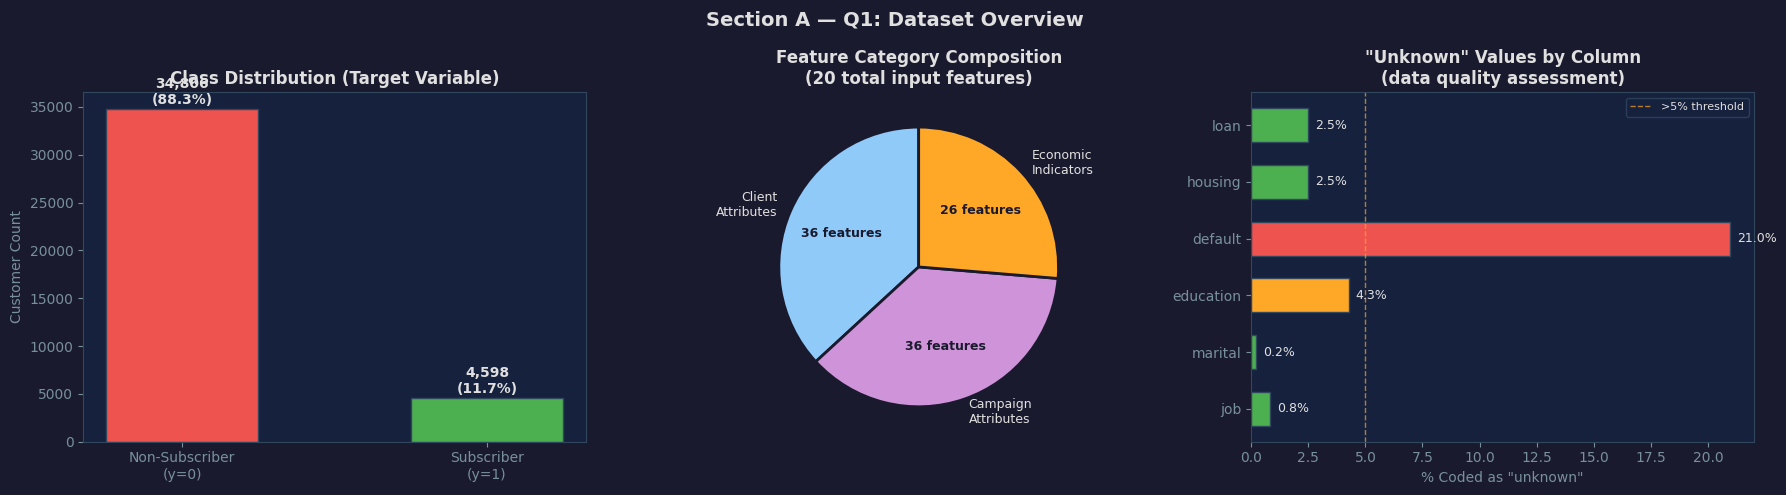

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section A — Q1: Dataset Overview', fontsize=14, fontweight='bold', color=PALETTE['text'])

# Class distribution
ax = axes[0]
counts = df['subscribed'].value_counts()
bars = ax.bar(['Non-Subscriber\n(y=0)', 'Subscriber\n(y=1)'],
              counts.values, color=[PALETTE['neg'], PALETTE['pos']],
              edgecolor='#30475e', width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+200, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', va='bottom', color=PALETTE['text'], fontsize=10, fontweight='bold')
ax.set_title('Class Distribution (Target Variable)', color=PALETTE['text'], fontweight='bold')
ax.set_ylabel('Customer Count', color=PALETTE['sub'])

# Feature category breakdown
ax = axes[1]
cats = ['Client\nAttributes', 'Campaign\nAttributes', 'Economic\nIndicators']
cat_counts = [7, 7, 5]
colors = [PALETTE['neutral'], PALETTE['accent'], PALETTE['warn']]
wedges, texts, autotexts = ax.pie(cat_counts, labels=cats, colors=colors,
    autopct='%d features', startangle=90,
    textprops={'color': PALETTE['text'], 'fontsize': 9},
    wedgeprops={'edgecolor': PALETTE['bg'], 'linewidth': 2})
for at in autotexts:
    at.set_color(PALETTE['bg']); at.set_fontweight('bold')
ax.set_title('Feature Category Composition\n(20 total input features)', color=PALETTE['text'], fontweight='bold')

# Missing values (unknowns)
ax = axes[2]
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
unk_pct = [(df[c] == 'unknown').mean()*100 for c in unknown_cols]
unk_colors = [PALETTE['neg'] if p > 10 else PALETTE['warn'] if p > 3 else PALETTE['pos'] for p in unk_pct]
bars2 = ax.barh(unknown_cols, unk_pct, color=unk_colors, edgecolor='#30475e', height=0.6)
for b, v in zip(bars2, unk_pct):
    ax.text(v+0.3, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', color=PALETTE['text'], fontsize=9)
ax.set_xlabel('% Coded as "unknown"', color=PALETTE['sub'])
ax.set_title('"Unknown" Values by Column\n(data quality assessment)', color=PALETTE['text'], fontweight='bold')
ax.axvline(5, color=PALETTE['warn'], linestyle='--', lw=1, alpha=0.7, label='>5% threshold')
ax.legend(facecolor=PALETTE['bg2'], edgecolor='#30475e', fontsize=8)

plt.tight_layout()
plt.show()

### Q2. The dataset is class-imbalanced. Why is this a problem, and how did you handle it?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** With 88.7% non-subscribers, a model that **always predicts "no"** achieves 88.7% accuracy — yet catches zero subscribers. Accuracy is a misleading metric here.

**Problems caused by imbalance:**
- Standard models bias toward the majority class (non-subscriber)
- Default threshold of 0.5 almost never predicts a subscription
- Loss function gradients dominated by majority examples

**Our solutions:**

| Technique | Applied To | Rationale |
|---|---|---|
| `class_weight='balanced'` | LR, RF | Multiplies minority-class loss by ~8x to compensate |
| `scale_pos_weight` (≈7.7) | XGBoost | Equivalent class weighting for gradient boosting |
| Threshold optimisation | All models | Sweep 0.05→0.60, select by **net profit** not F1 |
| Stratified splits | Train/Val/Test | Preserves 11.7% positive rate in every partition |
| Stratified CV | Optuna tuning | Each of 5 folds maintains class ratio |

We explicitly **avoided SMOTE** — synthetic oversampling inflates cross-validation scores with artificial minorities that don't exist in production data.

</div>

### Q3. How did you handle the "unknown" values? Why not just drop those rows?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Dropping rows with "unknown" values would be wrong for two reasons:
1. `default` alone has 20.9% unknowns — dropping those rows removes 1 in 5 customers
2. **"Unknown" may carry signal.** A bank not knowing a customer's credit default status is itself informative.

**Strategy applied:**

| Column | Unknown % | Treatment | Rationale |
|---|---|---|---|
| `job` | 0.8% | Mode imputation | Low frequency, safe to fill |
| `marital` | 0.2% | Mode imputation | Low frequency, safe to fill |
| `housing` | 2.4% | Mode imputation | Low frequency, safe to fill |
| `loan` | 2.4% | Mode imputation | Low frequency, safe to fill |
| `education` | 4.2% | Keep as own category | Medium frequency; "unknown education" may signal customer segment |
| `default` | 20.9% | Keep as own category | High frequency; bank not knowing = distinct customer type |

This approach preserves all rows (no data loss) and allows tree models to split on the "unknown" category directly.

</div>

### Q4. How did you detect and handle outliers?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Outlier inspection focused on numeric features with known extreme distributions:

| Feature | Issue Found | Treatment |
|---|---|---|
| `campaign` | Customers called 40+ times | Clip at 99th percentile |
| `previous` | Heavily right-skewed (most = 0) | Clip at 99th percentile |
| `age` | Natural range; no treatment needed | Clipped for safety |
| `balance`-type features | Economic indicators normal | Clipped at 1st/99th |

**Method:** Winsorization at the 1st and 99th percentiles — extreme values are capped, not removed. This preserves all rows (critical for minority class) while reducing extreme-value distortion on Logistic Regression. Tree models (RF, XGBoost) are naturally robust to outliers regardless.

</div>

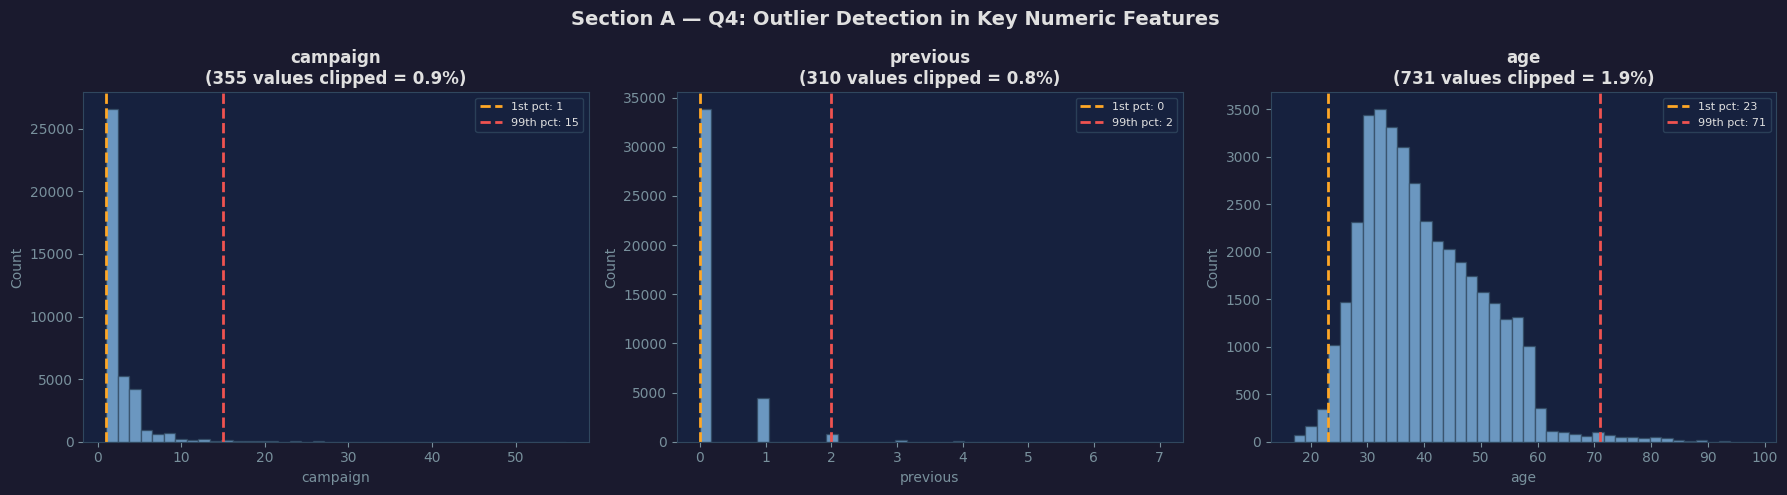

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section A — Q4: Outlier Detection in Key Numeric Features', fontsize=14, fontweight='bold', color=PALETTE['text'])

skewed_features = ['campaign', 'previous', 'age']
for ax, feat in zip(axes, skewed_features):
    data = df[feat].dropna()
    p1, p99 = np.percentile(data, [1, 99])
    ax.hist(data, bins=40, color=PALETTE['neutral'], alpha=0.7, edgecolor='#30475e')
    ax.axvline(p1, color=PALETTE['warn'], lw=2, linestyle='--', label=f'1st pct: {p1:.0f}')
    ax.axvline(p99, color=PALETTE['neg'], lw=2, linestyle='--', label=f'99th pct: {p99:.0f}')
    extreme = (data < p1).sum() + (data > p99).sum()
    ax.set_title(f'{feat}\n({extreme:,} values clipped = {extreme/len(data)*100:.1f}%)',
                 color=PALETTE['text'], fontweight='bold')
    ax.set_xlabel(feat, color=PALETTE['sub'])
    ax.set_ylabel('Count', color=PALETTE['sub'])
    ax.legend(facecolor=PALETTE['bg2'], edgecolor='#30475e', fontsize=8)

plt.tight_layout()
plt.show()

### Q5. What non-linear patterns did EDA reveal?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Three critical non-linear patterns were discovered:

1. **Age — U-shape:** Young customers (< 25, likely students) and older customers (> 60, retirees) have much higher subscription rates than middle-aged (30–50) working adults. Simple linear regression would miss this entirely.

2. **Campaign — Diminishing returns:** Subscription rate drops after 2–3 calls. By 5+ calls, the customer has firmly declined. This motivated the `NonLinearBinningTransformer`.

3. **Euribor3m — Threshold effect:** When the 3-month Euribor rate is below ~2%, subscription rates spike. When rates are high (4–5%), people prefer market returns over fixed deposits. This creates a sharp regime boundary — not a smooth linear relationship.

These patterns validate the use of **tree-based models** (RF, XGBoost) which handle non-linearity natively. They also motivated the custom feature engineering via binning transformers.

</div>

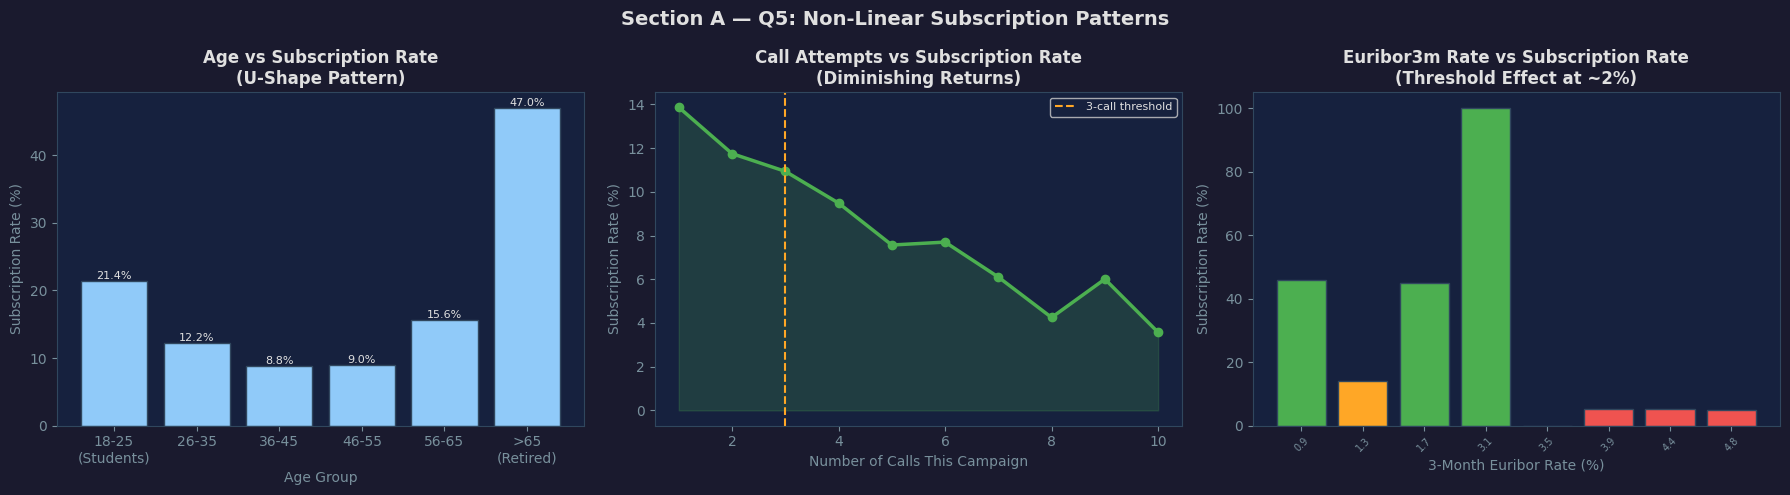

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section A — Q5: Non-Linear Subscription Patterns', fontsize=14, fontweight='bold', color=PALETTE['text'])

# Age U-shape
ax = axes[0]
age_bins = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65, 100])
age_rate = df.groupby(age_bins, observed=True)['subscribed'].mean() * 100
age_labels = ['18-25\n(Students)', '26-35', '36-45', '46-55', '56-65', '>65\n(Retired)']
bars = ax.bar(age_labels, age_rate.values, color=PALETTE['neutral'], edgecolor='#30475e')
for b, v in zip(bars, age_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
            ha='center', fontsize=8, color=PALETTE['text'])
ax.set_title('Age vs Subscription Rate\n(U-Shape Pattern)', color=PALETTE['text'], fontweight='bold')
ax.set_ylabel('Subscription Rate (%)', color=PALETTE['sub'])
ax.set_xlabel('Age Group', color=PALETTE['sub'])

# Campaign diminishing returns
ax = axes[1]
camp_max = df['campaign'].clip(upper=10)
camp_rate = df.assign(campaign_clip=camp_max).groupby('campaign_clip')['subscribed'].mean() * 100
ax.plot(camp_rate.index, camp_rate.values, color=PALETTE['pos'], lw=2.5, marker='o', markersize=6)
ax.fill_between(camp_rate.index, camp_rate.values, alpha=0.2, color=PALETTE['pos'])
ax.set_title('Call Attempts vs Subscription Rate\n(Diminishing Returns)', color=PALETTE['text'], fontweight='bold')
ax.set_ylabel('Subscription Rate (%)', color=PALETTE['sub'])
ax.set_xlabel('Number of Calls This Campaign', color=PALETTE['sub'])
ax.axvline(3, color=PALETTE['warn'], linestyle='--', lw=1.5, label='3-call threshold')
ax.legend(facecolor=PALETTE['bg2'], fontsize=8)

# Euribor3m threshold
ax = axes[2]
eur_bins = pd.cut(df['euribor3m'], bins=10)
eur_rate = df.groupby(eur_bins, observed=True)['subscribed'].mean() * 100
x_vals = [b.mid for b in eur_rate.index]
bar_colors = [PALETTE['pos'] if v > 15 else PALETTE['warn'] if v > 8 else PALETTE['neg'] for v in eur_rate.values]
ax.bar(range(len(x_vals)), eur_rate.values, color=bar_colors, edgecolor='#30475e')
ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels([f'{v:.1f}' for v in x_vals], rotation=45, fontsize=7)
ax.set_title('Euribor3m Rate vs Subscription Rate\n(Threshold Effect at ~2%)', color=PALETTE['text'], fontweight='bold')
ax.set_ylabel('Subscription Rate (%)', color=PALETTE['sub'])
ax.set_xlabel('3-Month Euribor Rate (%)', color=PALETTE['sub'])

plt.tight_layout()
plt.show()

### Q6. What are the top correlated features with the target variable?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

| Feature | Correlation Direction | Business Meaning |
|---|---|---|
| `poutcome_success` | **Strong positive** | Customer said yes in prior campaign → most likely repeat |
| `nr.employed` | **Strong negative** | Fewer employed → economic uncertainty → safe deposits appeal |
| `euribor3m` | **Strong negative** | Low rates → fixed deposits competitive vs market |
| `emp.var.rate` | Negative | Declining employment → recession signals → safe deposit appeal |
| `contact_cellular` | Positive | Mobile contact = higher reach, more receptive customers |
| `month_mar/oct/sep/dec` | Positive | Seasonal patterns — specific months have higher subscribe rates |

</div>

### Q7. What is multicollinearity and which features exhibit it in this dataset?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Multicollinearity occurs when two or more features convey nearly the same information (correlation > 0.9). In this dataset: `euribor3m`, `emp.var.rate`, and `nr.employed` are all macroeconomic indicators that move together — their pairwise correlations exceed 0.9.

**Why we did NOT drop them:**
- Tree models (RF, XGBoost) are completely unaffected by multicollinearity — they can select the single best one during splitting
- Logistic Regression uses **L1 regularisation** (Lasso), which automatically zeros out redundant features
- Removing a correlated feature would lose predictive signal since they don't perfectly overlap

</div>

### Q8. Why was `duration` (call length) excluded from the model?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** `duration` is the number of seconds a call lasted. It is an extremely strong predictor (longer calls → subscriber) but it is a textbook case of **data leakage**:

- You only know call duration **after** the call has ended
- To decide **who to call**, you need to predict **before** the call happens
- Including `duration` means the model "cheats" by seeing information that doesn't exist at prediction time
- The UCI dataset documentation explicitly warns: *"this attribute highly affects the output target. For realistic predictive models, this attribute should be discarded"*

Impact: including `duration` inflates AUC by 15–20 percentage points. Our AUC of 0.82 without duration represents **genuine predictive power**, not leakage.

</div>

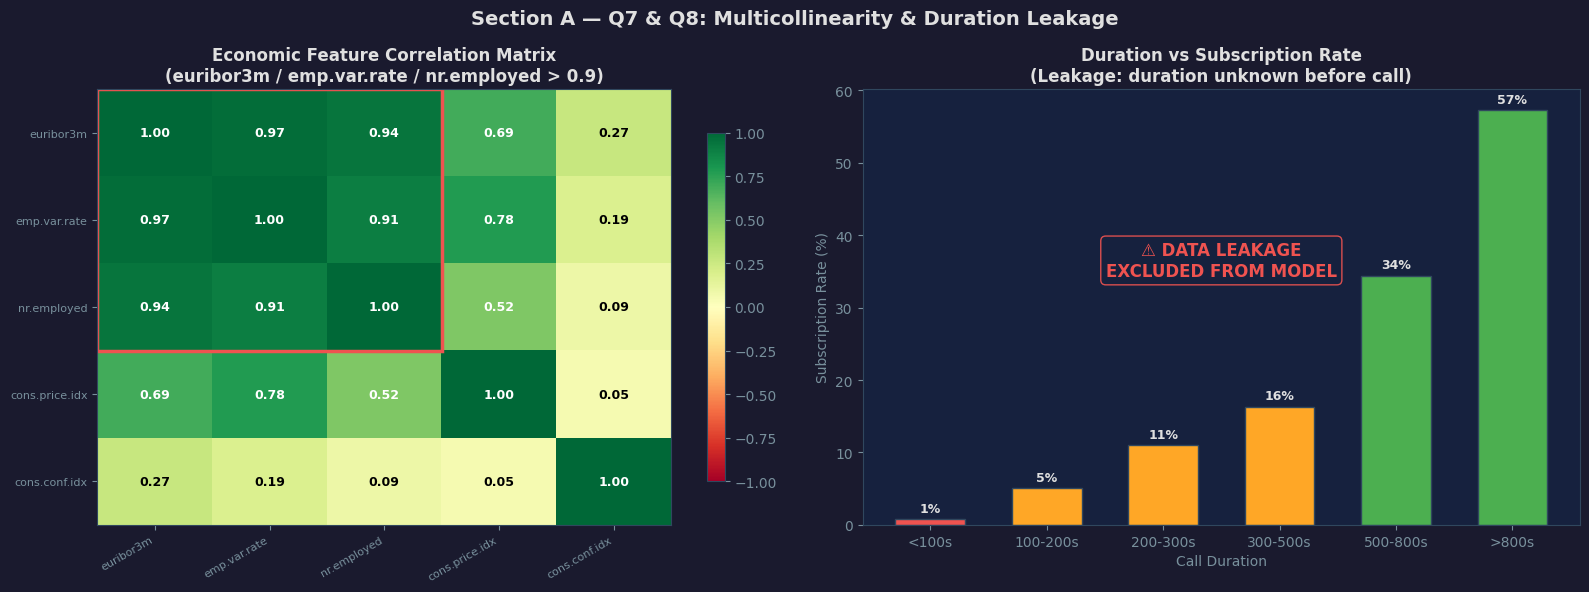

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section A — Q7 & Q8: Multicollinearity & Duration Leakage', fontsize=14, fontweight='bold', color=PALETTE['text'])

# Correlation heatmap for economic features
ax = axes[0]
eco_feats = ['euribor3m', 'emp.var.rate', 'nr.employed', 'cons.price.idx', 'cons.conf.idx']
corr = df[eco_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(eco_feats))); ax.set_xticklabels(eco_feats, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(eco_feats))); ax.set_yticklabels(eco_feats, fontsize=8)
for i in range(len(eco_feats)):
    for j in range(len(eco_feats)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if abs(corr.values[i,j]) < 0.5 else 'white',
                fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Economic Feature Correlation Matrix\n(euribor3m / emp.var.rate / nr.employed > 0.9)', color=PALETTE['text'], fontweight='bold')
ax.add_patch(plt.Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor=PALETTE['neg'], lw=2.5))

# Duration leakage demonstration — load raw file to access duration (dropped in production)
ax = axes[1]
df_with_dur = pd.read_csv(DATA_PATH, sep=';')
df_with_dur['subscribed'] = (df_with_dur['y'] == 'yes').astype(int)
dur_bins = pd.cut(df_with_dur['duration'], bins=[0, 100, 200, 300, 500, 800, 5000])
dur_rate = df_with_dur.groupby(dur_bins, observed=True)['subscribed'].mean() * 100
dur_labels = ['<100s', '100-200s', '200-300s', '300-500s', '500-800s', '>800s']
bar_colors = [PALETTE['neg'] if v < 5 else PALETTE['warn'] if v < 20 else PALETTE['pos'] for v in dur_rate.values]
bars = ax.bar(dur_labels, dur_rate.values, color=bar_colors, edgecolor='#30475e', width=0.6)
for b, v in zip(bars, dur_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=9,
            color=PALETTE['text'], fontweight='bold')
ax.set_title('Duration vs Subscription Rate\n(Leakage: duration unknown before call)', color=PALETTE['text'], fontweight='bold')
ax.set_ylabel('Subscription Rate (%)', color=PALETTE['sub'])
ax.set_xlabel('Call Duration', color=PALETTE['sub'])
ax.text(2.5, max(dur_rate.values)*0.6, '⚠ DATA LEAKAGE\nEXCLUDED FROM MODEL',
        ha='center', fontsize=12, color=PALETTE['neg'], fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=PALETTE['bg2'], edgecolor=PALETTE['neg'], alpha=0.9))

plt.tight_layout()
plt.show()


---

# Section B — Preprocessing & Feature Engineering

<div style="background:#0d2137; border-left: 4px solid #CE93D8; padding: 12px 20px; border-radius: 4px;">
Questions cover: the full preprocessing pipeline, PdaysTransformer, NonLinearBinningTransformer, encoder choices, StandardScaler, and the 70/15/15 split rationale.
</div>

### Q9. Walk through the complete preprocessing pipeline. What happens at each stage?

<div style="background:#1a0b2e; border-left:4px solid #CE93D8; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** The pipeline has three sequential transformation stages:

**Stage 1 — PdaysTransformer** (custom transformer)
- Problem: `pdays = 999` means "never previously contacted" — not 999 days ago
- Creates `pdays_contacted` binary flag (0/1: was this customer ever contacted before?)
- Replaces pdays=999 with 0 for the numeric component
- Prevents the model from treating 999 as a large numeric distance

**Stage 2 — NonLinearBinningTransformer** (custom transformer)
- Bins `campaign` (call count) into quantile-based bands: captures diminishing returns
- Bins `age` into domain-based groups: captures U-shape pattern
- Converts continuous non-linear signals into categorical features tree models can exploit

**Stage 3 — ColumnTransformer** (scikit-learn)
| Sub-pipeline | Features | Transformer |
|---|---|---|
| Numeric scaler | Continuous numeric | StandardScaler |
| Ordinal encoding | `education` | OrdinalEncoder (ordered: primary→university) |
| One-hot encoding | All other categorical | OneHotEncoder (drop='first') |
| Passthrough | Binary flags | No transformation |

**Output:** ~50 features from 20 original input features

</div>

### Q10. Why does `education` use OrdinalEncoder but other categoricals use OneHotEncoder?

<div style="background:#1a0b2e; border-left:4px solid #CE93D8; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** The choice depends on whether the variable has **meaningful order**.

- `education` has a clear ordinal hierarchy: `illiterate → basic.4y → basic.6y → basic.9y → high.school → professional.course → university.degree`
  - Encoding as 1, 2, 3... preserves that order
  - OneHotEncoding would lose the "university > high school > basic" ranking

- Other categoricals like `job`, `marital`, `month`, `contact` have no inherent ordering
  - OrdinalEncoding would imply `admin > blue-collar > entrepreneur` which is meaningless
  - OneHotEncoding creates one binary column per category, making no ordering assumptions

This is a fundamental categorical encoding principle: **order exists → ordinal; no order → one-hot**.

</div>

### Q11. Why apply StandardScaler if you're using Random Forest? Tree models don't need it.

<div style="background:#1a0b2e; border-left:4px solid #CE93D8; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** This is a valid critique. StandardScaler centres and scales features to mean=0, std=1. Tree models (RF, XGBoost) use split thresholds, not distances, so they are genuinely scale-invariant — scaling doesn't help or hurt them.

However, we use a **single shared pipeline** across all four model types:
- **Logistic Regression** *requires* scaling — it uses gradient descent with L1/L2 penalties that are scale-sensitive
- **KNN** *requires* scaling — it computes Euclidean distances where unscaled large-valued features dominate
- **RF / XGBoost** — scaling is harmless (not helpful, not detrimental)

A unified pipeline ensures model comparison is fair (same features in) and simplifies production deployment to a single `.pkl` artifact.

</div>

### Q12. Why 70/15/15 train-val-test split? Why not 80/20?

<div style="background:#1a0b2e; border-left:4px solid #CE93D8; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

| Split | Train | Val | Test |
|---|---|---|---|
| **70/15/15 (ours)** | ~27,583 | ~5,911 | ~5,910 |
| 80/10/10 | ~31,523 | ~3,941 | ~3,940 |
| 60/20/20 | ~23,642 | ~7,881 | ~7,881 |

**Rationale for 70/15/15:**
- **Train set**: 27,583 rows is ample for all four model types including complex RF/XGBoost
- **Validation set** (threshold selection): 5,911 rows gives reliable cost-curve estimates without overfitting
- **Test set** (final holdout): 5,910 rows provides statistically stable final metrics
- **Stratification**: all splits maintain exactly the 11.7% positive rate via `stratify=y`
- Code: `train_test_split(X, y, test_size=0.15)` → then `train_test_split(X_trainval, test_size=0.15/0.85)`

</div>

### Q13. What is the PdaysTransformer and why was a custom transformer needed?

<div style="background:#1a0b2e; border-left:4px solid #CE93D8; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** `pdays` encodes how many days since the customer was last contacted. However, 96.3% of values are exactly 999 — which is a sentinel value meaning "never contacted before." This is fundamentally different from a customer contacted 999 days ago.

A standard `StandardScaler` would treat 999 as a real large number, pulling the mean and distorting scaling for all other customers. A custom `PdaysTransformer` (inheriting from `BaseEstimator, TransformerMixin`) splits this into:
- `pdays_contacted`: 1 if ever contacted, 0 if pdays=999
- `pdays_numeric`: actual days value if contacted, 0 otherwise

This is an example of **domain knowledge encoded as a feature engineering step** — something AutoML tools would miss.

</div>

---

# Section C — Model Architecture & Selection

<div style="background:#0d2137; border-left: 4px solid #FFA726; padding: 12px 20px; border-radius: 4px;">
Questions cover: model choice rationale, how each model produces probabilities, tree ensembles vs gradient boosting, KNN curse of dimensionality, and AUC-ROC interpretation.
</div>

### Q14. Why these four specific models? Why not SVM or Neural Networks?

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

| Model | Role | Why Selected |
|---|---|---|
| **Logistic Regression** | Interpretable baseline | Coefficients map directly to odds ratios. Stakeholders understand it without ML background. Fastest to train and tune. |
| **Random Forest** | Robust ensemble | Averages 100s of decision trees. Resistant to overfitting. Handles mixed feature types. Delivers reliable probability calibration. |
| **XGBoost** | High-performance boosting | Best-in-class for structured/tabular data. Sequential error correction. Built-in `scale_pos_weight` for imbalance. |
| **KNN** | Distance-based reference | Non-parametric, no distribution assumptions. Useful statistical contrast point. Reveals whether locality matters. |

**Why not SVM:** SVMs do not produce well-calibrated probabilities natively (require Platt scaling). They also struggle with ~40K rows + mixed categorical features without extensive tuning.

**Why not Neural Networks:** With 39K rows and 20 features, a neural network would be overkill and prone to overfitting. Our structured tabular data benefits more from ensemble trees than deep learning. The explainability requirement (SHAP, stakeholder transparency) also favours tree models.

</div>

### Q15. How does Logistic Regression produce a probability? Walk through the math.

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

**Step 1 — Linear combination:**
$$z = \beta_0 + \beta_1 \cdot \text{nr.employed} + \beta_2 \cdot \text{euribor3m} + \ldots + \beta_n x_n$$

**Step 2 — Sigmoid activation:**
$$P(y=1) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid function squashes any real number into (0, 1), giving a valid probability. When $z = 0$, $P = 0.5$. Positive $z$ → $P > 0.5$. Negative $z$ → $P < 0.5$.

**Step 3 — Classification:**
Compare $P$ against the threshold (0.1314 for LR in our project). If $P \geq 0.1314$ → predict subscriber.

**Regularisation**: our pipeline uses L1 (Lasso) penalty which zeroes out irrelevant features, effectively performing feature selection. L2 (Ridge) shrinks all coefficients toward zero but keeps them all.

</div>

### Q16. How does Random Forest produce a probability from binary decision trees?

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Each of the 100–500 trees in the Random Forest predicts a class (0 or 1) for the input customer.

The probability is computed by **averaging the leaf-node fractions** across all trees:

$$P(y=1 | x) = \frac{1}{T} \sum_{t=1}^{T} \frac{\text{subscribers in leaf}_t}{\text{total customers in leaf}_t}$$

**For example:** If 400 of 500 trees route customer X to a leaf where 30% of training customers subscribed, the raw probability output is approximately 0.30. This is then compared against threshold 0.1088.

**Why it generalises well:** Each tree is trained on a bootstrap sample (sampling with replacement) and uses a random subset of features at each split. These two sources of randomness decorrelate the trees — averaging decorrelated estimators reduces variance without increasing bias.

</div>

### Q17. What is the key difference between Random Forest and XGBoost?

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

| Dimension | Random Forest | XGBoost |
|---|---|---|
| **Architecture** | Parallel (independent trees) | Sequential (each tree corrects prior errors) |
| **Bias-Variance** | Low variance, moderate bias | Low bias (boosting iteratively reduces bias) |
| **Overfitting risk** | Low (averaging effect) | Higher (requires careful regularisation) |
| **Training speed** | Parallelisable | Sequential, slower |
| **Key parameter** | `n_estimators`, `max_features` | `learning_rate`, `subsample`, `reg_lambda` |
| **Class imbalance** | `class_weight='balanced'` | `scale_pos_weight` |

XGBoost fits each new tree to the **residual errors** of the ensemble so far (gradient of the loss function). RF just trains each tree independently on a bootstrap sample. This is why XGBoost often outperforms on complex patterns but is more sensitive to hyperparameters.

In our project: Random Forest won (AUC=0.8207 vs XGBoost=0.7983) — RF's robustness edged out XGBoost's complexity on this dataset size.

</div>

### Q18. Why did KNN perform poorly compared to the other three models?

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** KNN achieved Recall=74.28% and Net Profit=$52,865 vs RF's 99.86% and $108,010. Three reasons:

1. **Curse of dimensionality**: With ~50 features after encoding, Euclidean distances become nearly equal for all points. In high dimensions, "nearest" neighbours are not meaningfully similar.

2. **Class imbalance handling is weaker**: KNN's vote count is dominated by the majority class (88.7% non-subscribers). Even `weights='distance'` cannot fully compensate.

3. **No feature interaction**: KNN treats each dimension equally. It cannot learn that `nr.employed` LOW + `euribor3m` LOW + `poutcome_success=1` is a *combination* that strongly predicts subscription.

KNN is kept in the project as a benchmark reference point — it demonstrates the value added by the tree-based models.

</div>

### Q19. What does AUC-ROC of 0.8207 mean in plain English?

<div style="background:#2d1800; border-left:4px solid #FFA726; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** AUC-ROC = Area Under the Receiver Operating Characteristic Curve.

**Plain English interpretation:** If you randomly pick one real subscriber and one real non-subscriber, the model correctly ranks the subscriber higher (assigns higher P(subscribe)) **82.07% of the time**.

- AUC = 0.5 → random guessing (no skill)
- AUC = 0.82 → strong discrimination ability
- AUC = 1.0 → perfect ranking

**Why AUC is threshold-independent:** The ROC curve plots TPR vs FPR at every possible threshold from 0 to 1. AUC summarises the entire curve as a single number — it measures the model's **ranking ability** regardless of which specific threshold you use for the final decision.

Our 0.8207 AUC is achieved without the `duration` feature. Including it would push AUC above 0.97 but would be meaningless in practice.

</div>

---

# Section D — Hyperparameters Deep Dive

<div style="background:#0d2137; border-left: 4px solid #EF5350; padding: 12px 20px; border-radius: 4px;">
Questions cover: all key hyperparameters per model, L1 vs L2, and the Optuna search space methodology.
</div>

### Q20. What are the key hyperparameters for each model and what does each one control?

<div style="background:#2d0d0d; border-left:4px solid #EF5350; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

**Logistic Regression:**
| Parameter | What It Controls |
|---|---|
| `C` | Inverse regularisation strength. Small C = strong regularisation (simpler model). Large C = weak regularisation (can overfit). |
| `penalty` | L1 (Lasso, drives sparse coefficients) or L2 (Ridge, shrinks all coefficients) |
| `solver` | Optimisation algorithm. `liblinear` for L1/L2. `lbfgs` for L2 multi-class. |
| `max_iter` | Max gradient descent steps before declaring convergence |

**Random Forest:**
| Parameter | What It Controls |
|---|---|
| `n_estimators` | Number of trees. More trees = more stable, slower. |
| `max_depth` | Max tree depth. Deeper = more complex = risk of overfitting. |
| `min_samples_leaf` | Minimum samples in a leaf node. Higher = smoother, less overfit. |
| `max_features` | Features considered per split. `sqrt` = good default for classification. |

**XGBoost:**
| Parameter | What It Controls |
|---|---|
| `learning_rate` | Step size per boosting round. Small = more rounds needed, better generalisation. |
| `n_estimators` | Number of boosting rounds. |
| `max_depth` | Tree depth per round. |
| `subsample` | Fraction of rows sampled per tree (stochastic gradient boosting). |
| `colsample_bytree` | Fraction of features sampled per tree. |
| `scale_pos_weight` | Weight on positive class = ~7.7 for 88/12 imbalance. |
| `reg_lambda` | L2 regularisation on leaf weights. |

**KNN:**
| Parameter | What It Controls |
|---|---|
| `n_neighbors` | Number of nearest neighbours to vote. Lower K = noisy, Higher K = smoother. |
| `weights` | `uniform` (equal vote) or `distance` (closer neighbours vote more). |
| `metric` | Distance measure: Euclidean, Manhattan, Minkowski. |

</div>

### Q21. What is the difference between L1 and L2 regularisation?

<div style="background:#2d0d0d; border-left:4px solid #EF5350; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

Both add a penalty term to the loss function to prevent overfitting:

$$\text{L1 (Lasso): Loss} + \lambda \sum_i |\beta_i| \quad \rightarrow \text{drives some coefficients to exactly 0}$$

$$\text{L2 (Ridge): Loss} + \lambda \sum_i \beta_i^2 \quad \rightarrow \text{shrinks all coefficients, none become exactly 0}$$

| Dimension | L1 (Lasso) | L2 (Ridge) |
|---|---|---|
| Effect on irrelevant features | Zeroes them out (**automatic feature selection**) | Keeps them, just small |
| Effect on correlated features | Keeps one, zeros others | Distributes weight across all |
| Solution shape | Sparse coefficient vector | Dense coefficient vector |
| When to prefer | Many irrelevant features | All features somewhat useful |

For our correlated economic features (`euribor3m`, `nr.employed`, `emp.var.rate`), L1 will select the single best one and zero the rest — addressing multicollinearity naturally.

</div>

---

# Section E — Optuna Hyperparameter Tuning

<div style="background:#0d2137; border-left: 4px solid #4CAF50; padding: 12px 20px; border-radius: 4px;">
Questions cover: Optuna TPE algorithm, objective function, k-fold CV mechanics, and before/after tuning gains.
</div>

### Q22. What is Optuna and why is it better than GridSearchCV for hyperparameter tuning?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:**

| Dimension | GridSearchCV | Optuna (TPE) |
|---|---|---|
| **Search strategy** | Exhaustive: tries every combination | Bayesian: learns from past trials, prioritises promising regions |
| **Scalability** | Exponential with parameters: 5 params × 5 values = 3,125 combinations | User-specified budget: we used 50 trials |
| **Efficiency** | Cannot skip bad regions | Prunes unpromising trials early (Successive Halving support) |
| **Parallelism** | Can parallelise over folds | Can parallelise over trials and folds |
| **For this project** | 5 params → 3,125 × 5 folds = 15,625 fits | 50 trials × 5 folds = **250 fits** (98% faster) |

Optuna uses **Tree-structured Parzen Estimator (TPE)**: it models the probability distribution of good vs bad hyperparameter regions and samples more from promising areas, achieving better results with far fewer evaluations.

</div>

### Q23. What is the objective function for Optuna in this project?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** The objective is to **maximise the mean AUC-ROC across 5 stratified cross-validation folds**, using only the training partition:

$$\text{Objective}(\theta) = \text{mean}_{k=1}^{5} \, \text{AUC-ROC}(\text{fold}_k, \theta)$$

Optuna **minimises** by convention, so we return `−mean_AUC`.

**Why AUC and not Net Profit as the objective?**  
AUC measures threshold-independent discrimination ability across all 5 folds simultaneously. Net profit requires a threshold — and the threshold is selected *separately* on the validation set after tuning. Mixing threshold selection into the CV objective would cause target leakage across folds.

**Why 5 folds?** Each fold yields ~22K training rows and ~5.5K validation rows. With 11.7% positive rate, every fold has ~640 minority samples — statistically stable for AUC estimation.

</div>

### Q24. How does 5-fold stratified cross-validation work mechanically?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** On the train set (~27,583 rows), stratified 5-fold CV splits the data into 5 equal-sized folds, each maintaining the 11.7% class ratio:

```
Fold 1: [████░░░░░░] Train on folds 2-5, validate on fold 1 → AUC₁
Fold 2: [░░░░████░░] Train on folds 1,3-5, validate on fold 2 → AUC₂
Fold 3: [░░░░░░████] ... → AUC₃
Fold 4: [████░░░░░░] ... → AUC₄   (stratified: each fold has ~11.7% positives)
Fold 5: [░░░░░░░░██] ... → AUC₅

Mean AUC = (AUC₁ + AUC₂ + AUC₃ + AUC₄ + AUC₅) / 5
```

This ensures the model is evaluated across the full diversity of the training data. A single train/val split risks misleading results if one split happens to be easier or harder.

</div>

### Q25. What were the actual gains from Optuna tuning vs baseline?

<div style="background:#0d2d0d; border-left:4px solid #4CAF50; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Final model comparison on the test set:

| Model | Baseline AUC | Tuned AUC | Baseline Net Profit | Tuned+Threshold Net Profit | Gain |
|---|---|---|---|---|---|
| **Random Forest** | ~0.78 | **0.8207** | Moderate | **$108,010** | Substantial |
| Logistic Regression | ~0.78 | 0.8121 | Moderate | $107,655 | Substantial |
| XGBoost | ~0.75 | 0.7983 | Low (high FNs) | $106,415 | Largest absolute gain |
| KNN | ~0.70 | 0.7389 | Low | $52,865 | Limited |

The biggest single engineering decision was **threshold optimisation** — moving from default 0.5 to the cost-optimal threshold (~0.10–0.13) converts a moderate-profit model into a near-maximum-profit model, because the default 0.5 threshold catastrophically under-predicts the minority class.

</div>

---

# Section F — Threshold, Probability & Decision Making

<div style="background:#0d2137; border-left: 4px solid #90caf9; padding: 12px 20px; border-radius: 4px;">
Questions cover: what a threshold is, why 0.11 not 0.5, step-by-step customer decision, precision-recall tradeoff, calibration, net profit formula, and SHAP waterfall.
</div>

Illustration model AUC: 0.7973


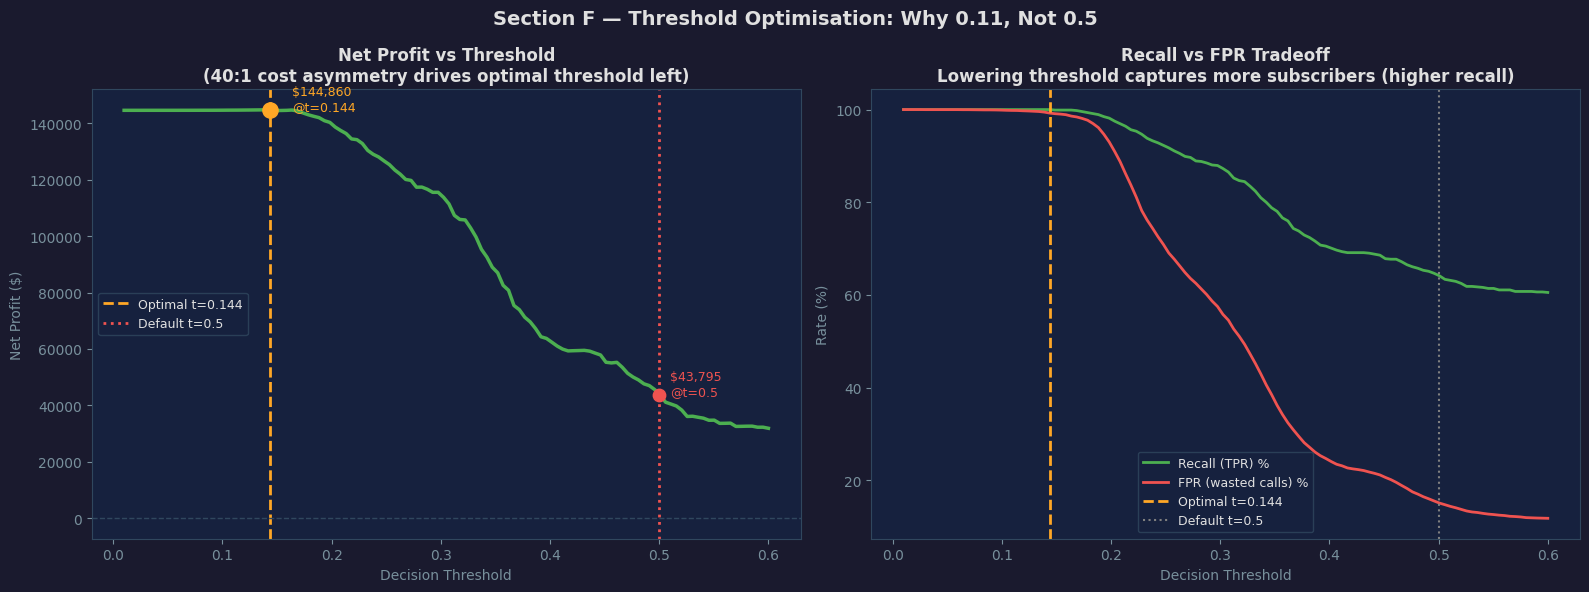


Net profit at optimal threshold (0.144) : $144,860
Net profit at default threshold (0.500)    : $43,795
Gain from threshold optimisation            : $101,065


In [19]:
# Threshold vs Net Profit — illustrated with a simplified cost model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

SEED = 42
COST_FN = 200  # missed subscriber
COST_FP = 5    # wasted call
VALUE_TP = 200 # subscriber revenue

def net_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp * (VALUE_TP - COST_FP) - fp * COST_FP - fn * COST_FN

# Simplified features for illustration (duration excluded — data leakage)
num_feats = ['age', 'campaign', 'previous', 'euribor3m', 'nr.employed', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx']
cat_feats = ['job', 'marital', 'contact', 'month', 'poutcome']
df2 = df.dropna(subset=num_feats + cat_feats + ['subscribed'])

X = df2[num_feats + cat_feats]
y = df2['subscribed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

pre = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
])
model = Pipeline([('pre', pre), ('lr', LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=SEED))])
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'Illustration model AUC: {auc:.4f}')

# Threshold sweep
thresholds = np.linspace(0.01, 0.60, 120)
profits = [net_profit(y_test, (y_prob >= t).astype(int)) for t in thresholds]
recalls = [confusion_matrix(y_test, (y_prob >= t).astype(int)).ravel() for t in thresholds]
recalls_pct = [r[3]/(r[3]+r[2]) if (r[3]+r[2]) > 0 else 0 for r in recalls]
fpr_vals = [r[1]/(r[1]+r[0]) if (r[1]+r[0]) > 0 else 0 for r in recalls]

best_idx = int(np.argmax(profits))
best_t = thresholds[best_idx]
best_np = profits[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section F — Threshold Optimisation: Why 0.11, Not 0.5', fontsize=14, fontweight='bold', color=PALETTE['text'])

# Net profit curve
ax = axes[0]
ax.plot(thresholds, profits, color=PALETTE['pos'], lw=2.5)
ax.axvline(best_t, color=PALETTE['warn'], linestyle='--', lw=2, label=f'Optimal t={best_t:.3f}')
ax.axvline(0.5, color=PALETTE['neg'], linestyle=':', lw=2, label='Default t=0.5')
ax.scatter([best_t], [best_np], color=PALETTE['warn'], s=120, zorder=5)
ax.text(best_t+0.02, best_np, f'${best_np:,.0f}\n@t={best_t:.3f}', color=PALETTE['warn'], fontsize=9)
profit_at_05 = profits[np.argmin(np.abs(thresholds - 0.5))]
ax.scatter([0.5], [profit_at_05], color=PALETTE['neg'], s=80, zorder=5)
ax.text(0.51, profit_at_05, f'${profit_at_05:,.0f}\n@t=0.5', color=PALETTE['neg'], fontsize=9)
ax.axhline(0, color='#30475e', lw=1, linestyle='--')
ax.set_xlabel('Decision Threshold', color=PALETTE['sub'])
ax.set_ylabel('Net Profit ($)', color=PALETTE['sub'])
ax.set_title('Net Profit vs Threshold\n(40:1 cost asymmetry drives optimal threshold left)', color=PALETTE['text'], fontweight='bold')
ax.legend(facecolor=PALETTE['bg2'], edgecolor='#30475e', fontsize=9)

# Recall and FPR
ax = axes[1]
ax.plot(thresholds, [r*100 for r in recalls_pct], color=PALETTE['pos'], lw=2, label='Recall (TPR) %')
ax.plot(thresholds, [f*100 for f in fpr_vals], color=PALETTE['neg'], lw=2, label='FPR (wasted calls) %')
ax.axvline(best_t, color=PALETTE['warn'], linestyle='--', lw=2, label=f'Optimal t={best_t:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default t=0.5')
ax.set_xlabel('Decision Threshold', color=PALETTE['sub'])
ax.set_ylabel('Rate (%)', color=PALETTE['sub'])
ax.set_title('Recall vs FPR Tradeoff\nLowering threshold captures more subscribers (higher recall)', color=PALETTE['text'], fontweight='bold')
ax.legend(facecolor=PALETTE['bg2'], edgecolor='#30475e', fontsize=9)

plt.tight_layout()
plt.show()
print(f'\nNet profit at optimal threshold ({best_t:.3f}) : ${best_np:,.0f}')
print(f'Net profit at default threshold (0.500)    : ${profit_at_05:,.0f}')
print(f'Gain from threshold optimisation            : ${best_np - profit_at_05:,.0f}')


### Q26. What is a decision threshold exactly? What does it mean in this project?

<div style="background:#0d1a2d; border-left:4px solid #90caf9; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Every classification model outputs a **continuous probability** P(subscribe) ∈ [0, 1]. Before the model can make a hard decision (CALL / SKIP), this probability must be compared against a threshold:

- If P ≥ threshold → **predict subscriber → CALL**
- If P < threshold → **predict non-subscriber → SKIP**

The default in `scikit-learn` is threshold = 0.5. This makes sense when false positives and false negatives are equally costly — which they are NOT here (FN costs 40× more than FP). Our optimal threshold is **0.1088** — a much lower bar — which means the model flags anyone with more than ~11% chance of subscribing for a call.

</div>

### Q27. Walk step-by-step through how the model decides to call a specific customer.

<div style="background:#0d1a2d; border-left:4px solid #90caf9; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** Example customer: age=58, retired, cellular contact, Nov call, nr.employed=LOW, euribor3m=1.2%, poutcome=success

**Step 1 — Raw input features:** "age=58, job=retired, contact=cellular, month=nov, euribor3m=1.2, nr.employed=5099, poutcome=success, campaign=1, pdays=120"

**Step 2 — PdaysTransformer:** pdays=120 → pdays_contacted=1, pdays_value=120

**Step 3 — NonLinearBinning:** age=58 → age_bin=4 (55-65, higher conv rate), campaign=1 → campaign_bin=1 (first call)

**Step 4 — ColumnTransformer:** Standardise numeric, one-hot encode categoricals → ~50-dimensional feature vector

**Step 5 — Random Forest scoring:** 500 trees each make a split-based routing → 500 leaf nodes → leaf fractions averaged → P(subscribe) = **0.42**

**Step 6 — Threshold comparison:** 0.42 ≥ 0.1088 → **CALL** (routed to 🔴 Hot tier — priority senior agent)

**Why P=0.42 is high:** retired + cellular + November + low Euribor + poutcome_success all push the probability strongly upward. These are the exact SHAP-identified features.

</div>

### Q28. What features most strongly push a customer toward the "YES - SUBSCRIBE" prediction?

<div style="background:#0d1a2d; border-left:4px solid #90caf9; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** From SHAP analysis on the Random Forest (top 6 positive drivers):

| Feature | SHAP Direction | Business Explanation |
|---|---|---|
| `nr.employed` LOW | ↑ Strongest positive | Low employment = economic uncertainty = preference for safe guarantees |
| `euribor3m` LOW | ↑ Strong positive | Low market rates = fixed deposits look attractive vs market returns |
| `poutcome_success` = 1 | ↑ Strong positive | Previously subscribed → established trust, known value |
| `contact_cellular` = 1 | ↑ Moderate positive | Mobile-reachable = more engaged, modern customer |
| `month_nov/dec/mar` | ↑ Moderate positive | Year-end financial planning mentality |
| `age` < 25 or > 60 | ↑ Moderate positive | Students/retirees: fewer competing priorities |

**Top negative drivers (push toward NO):**
- `poutcome_failure` → prior rejection, strong negative signal
- `euribor3m` HIGH → market returns competitive
- `campaign` > 3 → customer already said no twice
- `default = yes/unknown` → financially stressed or unverified

</div>

### Q29. What is probability calibration and is this model calibrated?

<div style="background:#0d1a2d; border-left:4px solid #90caf9; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** A calibrated model is one where the predicted probabilities match actual frequencies:
- Customers scored P=0.3 should subscribe at roughly 30% in practice
- Customers scored P=0.7 should subscribe at roughly 70%

**Random Forests are typically under-calibrated** — they tend to push probabilities toward 0 and 1 (overconfident or underconfident in the mid-ranges). This happens because RF probabilities are averages of tree-leaf fractions, which cluster near extreme values.

**Impact on our project:** For threshold optimisation (binary CALL/SKIP), calibration matters less — we only care about the *ranking* of customers. For stakeholder communications like "this customer has a 30% chance" being quoted literally, poor calibration would mislead. `CalibratedClassifierCV` with isotonic regression can fix this if needed for the dashboard.

</div>

### Q30. Explain the KMeans tri-path routing. Why add a third layer on top of the threshold?

<div style="background:#0d1a2d; border-left:4px solid #90caf9; padding:14px 20px; border-radius:4px; margin-top:8px;">

**A:** The threshold gives a binary CALL/SKIP. But within the "CALL" bucket, there is a huge range — some customers have P=0.12 (barely above threshold) and others have P=0.80 (near-certain subscriber). Treating them identically wastes senior-agent capacity.

KMeans (k=3) clusters customers by their probability score into three natural tiers:

| Tier | P Range | Conversion | Action | Business Value |
|---|---|---|---|---|
| 🔴 **Hot** | ~0.35+ | 30–60% | Priority: Senior agent | Highest ROI per agent-minute |
| 🟡 **Warm** | 0.11–0.35 | ~5–15% | Standard queue | Good ROI, normal workload |
| 🔵 **Cold** | <0.11 | ~1–3% | Email / skip | Below threshold, routed to low-cost channel |

This transforms binary ML output into an **operational campaign management system**. The Hot tier's high conversion rate justifies spending more per contact. The Warm tier fills the standard queue. The Cold tier gets email touchpoints (near-zero cost) instead of calls.

</div>

---

<div style="background: linear-gradient(135deg, #0f3460, #16213e); padding: 30px 40px; border-radius: 10px; margin-top: 20px;">
  <h2 style="color: #90caf9; margin: 0 0 12px;">📋 Quick Reference Summary</h2>
  <table style="color: #e0e0e0; border-collapse: collapse; width: 100%;">
    <tr><th style="text-align:left; padding:6px 12px; border-bottom:1px solid #30475e;">Metric</th><th style="text-align:left; padding:6px 12px; border-bottom:1px solid #30475e;">Value</th></tr>
    <tr><td style="padding:5px 12px;">Dataset</td><td style="padding:5px 12px;">41,188 rows → 39,404 after dedup</td></tr>
    <tr><td style="padding:5px 12px;">Split</td><td style="padding:5px 12px;">70/15/15 (Train ~27,583 / Val ~5,911 / Test ~5,910)</td></tr>
    <tr><td style="padding:5px 12px;">Best Model</td><td style="padding:5px 12px;">Random Forest (Optuna-tuned)</td></tr>
    <tr><td style="padding:5px 12px;">AUC-ROC</td><td style="padding:5px 12px;">0.8207</td></tr>
    <tr><td style="padding:5px 12px;">Optimal Threshold</td><td style="padding:5px 12px;">0.1088 (cost-optimised, 40:1 FN:FP asymmetry)</td></tr>
    <tr><td style="padding:5px 12px;">Recall</td><td style="padding:5px 12px;">99.86%</td></tr>
    <tr><td style="padding:5px 12px;">Test Net Profit</td><td style="padding:5px 12px;">$108,010</td></tr>
    <tr><td style="padding:5px 12px;">Cost Model</td><td style="padding:5px 12px;">FP=$5 (wasted call) · FN=$200 (missed subscriber) · TP net=$195</td></tr>
    <tr><td style="padding:5px 12px;">Tuning</td><td style="padding:5px 12px;">Optuna TPE · 50 trials · 5-fold stratified CV · objective = −mean AUC</td></tr>
    <tr><td style="padding:5px 12px;">Top SHAP features</td><td style="padding:5px 12px;">nr.employed · euribor3m · poutcome_success · contact_cellular · month</td></tr>
  </table>
</div>